***Problem 1*** 

part a.)

I'll try to get the formula for how long you end up waiting.

This is sorta markov chain based. Every flip we have a 50% chance of resetting or a 50% chance of incrementing the count 1. We can find the expected length of the chain through a recursive equation. For example:

n=1 we have a 50% chance to flip a correct call, or a 50% chance to reset our streak. $n_{1}$ = $\frac{1}{2}$(1+$n_{1}$) + $\frac{1}{2}$

This represents either  the state failing and resetting to go again with more tries, or the state reaching n=1. Solving for $n_{1}$ we see that:

$n_{1}$ = 2

Now we find some other test cases.

$n_{2}$ = $\frac{1}{2}$(1+$n_{2}$) + $\frac{1}{2^{2}}$(2+$n_{2}$) + $\frac{1}{2^{2}}$(2)

Note: the stuff in parentheses is like the number of coin flips we have to do. If we fail the first one, we add a flip but we then still need to go until we get 2 flips. At best it takes 2 flips to get 2 correct calls
Here our states are either failing the first flip and resetting to try again, making the first flip but failing the second(where we reset by 2 since we've now used 2 coin flips). And then the chance we get it. 

$n_{2}$ = (1+$\frac{1}{2}$)/$\frac{1}{2^{2}}$ = 3/2 / 1/4

$n_{2}$ = 6

$n_{3}$ = $\frac{1}{2}$(1+$n_{3}$) + $\frac{1}{2^{2}}$(2+$n_{2}$) + $\frac{1}{2^{3}}$(3+$n_{3}$) + $\frac{1}{2^{3}}$(3) and solving this we find
$n_{3}$ = 14

$n_{4}$ = $\frac{1}{2}$(1+$n_{4}$) + $\frac{1}{2^{2}}$(2+$n_{4}$) + $\frac{1}{2^{3}}$(3+$n_{4}$) + $\frac{1}{2^{4}}$(4+$n_{4}$) + $\frac{1}{2^{4}}$(4) and solving this we find
$n_{4}$ = 30

hmm 2, 6, 14, 30. I'll use the Online Encyclopedia of Integer Sequences and see if this comes up with something.

https://oeis.org/A000918 One of the comments on this specific one is about this problem so I think this is going to be correct

**$n_{x} = 2^{x} - 2$**

This however notes that for x heads you want to do x+1 as your power. So a better formula might be **$n_{x} = 2^{x+1} - 2$**

If we solve for $n_{14}$ we find it is $2^{15} - 2$

**$n_{14}$ = 32766**

part b.) 

Winning 14 coin tosses by chance is a slightly different question. The odds of that are just $\frac{1}{2^{14}}$. 

So we need to find the sigma value which gives us $1-\frac{1}{2^{14}}$ the ratio of the Gaussian's area

I will use scipy.stats.norm.ppf, which is an inverse function for the cdf of a normal distribution
Some numerical approximation surely happening behind the scenes since gaussian is non-invertable but the specifics don't matter that much here

scipy.stats.norm.ppf(1-(1/(2\*\*14))) = **3.841930685501911**

So it is a 3.84 sigma event, which is not our 5 sigma target.

In [47]:
from scipy.stats import norm
print(norm.ppf((1/(2**14))))

-3.841930685501911


***Problem 2***

Part a.)
Show $\langle ax + b \rangle = a\langle x \rangle + b$


\begin{aligned}
\text{Use the expectation value formula } \langle ax + b \rangle  &= \int x (ax + b)\, dx \\ 
\text{Distribute x } &= \int \left( x(ax) + x(b) \right) dx \\
\text{Break apart the integral } &= \int a x^2 \, dx + \int b x \, dx \\
\text{factor out a, and recognize <b> } &= a \int x^2 \, dx + \langle b \rangle \\
\text{Recognize <x>, and recognize <constant>=constant } &= a\langle x \rangle + b
\end{aligned}


---

Show $\mathrm{Var}(ax + b) = a^2 \mathrm{Var}(x)$

\begin{aligned}
\text{Use the variance formula <x^2>-<x>^2 } \mathrm{Var}(ax + b) &= \langle (ax + b)^2 \rangle - \langle ax + b \rangle^2 \\
\text{Expand out the first term and sub in the second term from previous problem } &= \langle a^2 x^2 + 2abx + b^2 \rangle - (a\langle x \rangle + b)^2 \\
\text{Expectation values can be broken apart } &= \langle a^2 x^2 \rangle + \langle 2abx \rangle + \langle b^2 \rangle 
   - (a\langle x \rangle + b)^2 \\
\text{Factor out constants } &= a^2 \langle x^2 \rangle + 2ab \langle x \rangle + b^2 
   - \left( a^2 \langle x \rangle^2 + 2ab \langle x \rangle + b^2 \right) \\
\text{Terms cancel } &= a^2 \left( \langle x^2 \rangle - \langle x \rangle^2 \right) \\
\text{Factor out $a^2$ } &= a^2 \mathrm{Var}(x)
\end{aligned}


part b.)
Consider random variables x,y. 

Show $Var(ax+y) = a^2Var(x) + Var(y) + 2aCov(x,y) = a^2Var(x) + Var(y) + 2a\rho\sigma_x\sigma_y$ using 
Cov(x, y) = $\langle x-\langle x \rangle\rangle \langle y - \langle y \rangle \rangle = \langle xy \rangle - \langle x \rangle \langle y \rangle$

========================================================================================================================

\begin{aligned}
\text{Use the variance formula <x^2>-<x>^2 } \mathrm{Var}(ax + y) &= \langle (ax + y)^2 \rangle - \langle ax + y \rangle^2 \\
\text{Expand out the terms like in part a.) } &= a^2 \langle x^2 \rangle + \langle y^2 \rangle + 2a \langle xy \rangle - (a^2 \langle x \rangle ^2 + \langle y \rangle ^2 + 2a \langle x \rangle \langle y \rangle) \\
\text{stuff cancells and factors } &= a^2(\langle x^2 \rangle-\langle x \rangle ^2) + (\langle y^2 \rangle-\langle y \rangle ^2) + (2a(\langle xy \rangle - \langle x \rangle \langle y \rangle)))   \\
\text{Substitute in variances } &= a^2\mathrm{Var}(x) + \mathrm{Var}(y) + 2a\mathrm{Cov}(x,y) \\
\text{We let Var(x) = $\sigma^2_x$ , $Var(y) = \sigma^2_y$ , and $\rho = Cov(x,y)/\sigma_x\sigma_y$ } &= a^2(σ2_x) + σ2_y + 2aσ_xσ_yρ \\
\end{aligned}

part b.)
Consider random variables x,y. 

Show $Var(ax+y) = a^2Var(x) + Var(y) + 2aCov(x,y) = a^2Var(x) + Var(y) + 2a\rho\sigma_x\sigma_y$ using 
Cov(x, y) = $\langle x-\langle x \rangle\rangle \langle y - \langle y \rangle \rangle = \langle xy \rangle - \langle x \rangle \langle y \rangle$

========================================================================================================================

\begin{aligned}
\text{Use the variance formula <x^2>-<x>^2 } \mathrm{Var}(ax + y) &= \langle (ax + y)^2 \rangle - \langle ax + y \rangle^2 \\
\text{Expand out the terms like in part a.) } &= a^2 \langle x^2 \rangle + \langle y^2 \rangle + 2a \langle xy \rangle - (a^2 \langle x \rangle ^2 + \langle y \rangle ^2 + 2a \langle x \rangle \langle y \rangle) \\
\text{stuff cancells and factors } &= a^2(\langle x^2 \rangle-\langle x \rangle ^2) + (\langle y^2 \rangle-\langle y \rangle ^2) + (2a(\langle xy \rangle - \langle x \rangle \langle y \rangle)))   \\
\text{Substitute in variances } &= a^2\mathrm{Var}(x) + \mathrm{Var}(y) + 2a\mathrm{Cov}(x,y) \\
\text{We let Var(x) = $\sigma^2_x$ , $Var(y) = \sigma^2_y$ , and $\rho = Cov(x,y)/\sigma_x\sigma_y$ } &= a^2(σ2_x) + σ2_y + 2aσ_xσ_yρ \\
\end{aligned}

part c.)
Using the fact Var(ax+y)>=0 and the results from b.), show ρ must be in the domain \[-1, 1\] inclusive

Let Var(ax+y) = 0, which is the minimum possible value since Var(ax+y) >= 0

$0 = a^2(\sigma^2_x) + 2a\sigma_x\sigma_y\rho + \sigma^2_y$

This is a quadratic formula with a, and we know that all values are greater than 0 so the quadratic is never negative
i.e. the discriminant $B^2-4AC$ must be less than 0
    
The discriminant is $(2\sigma_x\sigma_yρ)^2 -4(\sigma^2_x)(\sigma^2_y) = 4\sigma_x^2\sigma_y^2(ρ^2-1)$

Again, the discriminant must be less than or equal to 0. Since $\sigma_x$ and $\sigma_y$ will strictly be positive(or 0), $(\rho^2-1)$ must be negative or 0
    
$\rho^2-1 \leq 0$
         
$\rho^2 \leq 1$
    
$\rho \leq +/- 1 or |\rho| \leq 1$
    
$-1 \leq \rho \leq 1$

***Problem 3***

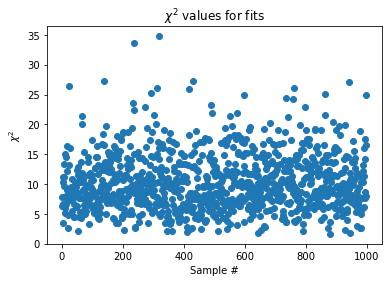

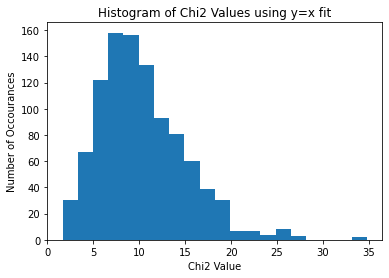

In [45]:
#Part a.)
#we just assume f(x) = x and calculate the chi^2 of that.

import numpy as np
import matplotlib.pyplot as plt

# 10 evenly spaced data points between 0.1 and 1
x = np.linspace(0.1, 1, 10)
temp=[]
for n in range(1000):
    # Randomly generate yi from y=x, varied by a Gaussian with sigma = 0.1
    yi = np.random.normal(x, 0.1)
    
    # Fit with a first-order polynomial (i.e. linear)
    fit = np.polyfit(x, yi, 1) 

    slope = fit[0]
    intercept = fit[1]
    chi2_fit = np.sum(
    ((yi - x) / 0.1)**2 #since we assume f(x) = x
    )
    temp.append(chi2_fit)
    
plt.scatter(range(1000), temp)    
plt.title(r'$\chi^2$ values for fits')
plt.ylabel(r'$\chi^2$')
plt.xlabel('Sample #')
plt.show()

plt.hist(temp, bins = 20)
plt.title('Histogram of Chi2 Values using y=x fit')
plt.xlabel('Chi2 Value')
plt.ylabel('Number of Occourances')
plt.show()

#This has 10 degrees of freedom. Degrees of freedom = # of data points - fit parameters
#and we have fixed the fit parameters. Slope = 1 and yint = 0 so these aren't free to move
#page 8 lecture 5

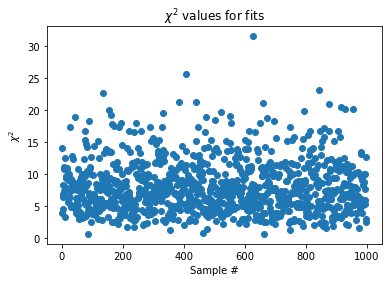

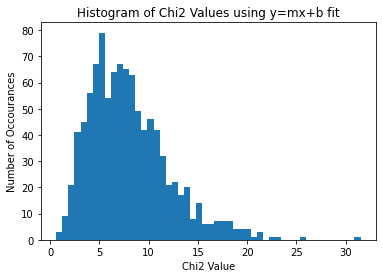

In [41]:
#Part b.)
#we allow slope and yint to be fit to. The code for this was already included in the example script

import numpy as np
import matplotlib.pyplot as plt

def Linear(x, slope, yint):
    return((slope*x) + yint)

# 10 evenly spaced data points between 0.1 and 1
x = np.linspace(0.1, 1, 10)
temp=[]
for n in range(1000):
    # Randomly generate yi from y=x, varied by a Gaussian with sigma = 0.1
    yi = np.random.normal(x, 0.1)
    
    # Fit with a first-order polynomial (i.e. linear)
    fit = np.polyfit(x, yi, 1) 

    slope = fit[0]
    intercept = fit[1]
    chi2_fit = np.sum(
    ((yi - Linear(x, slope, intercept)) / 0.1)**2 #since we assume f(x) = x
    )
    temp.append(chi2_fit)
    
plt.scatter(range(1000), temp)    
plt.title(r'$\chi^2$ values for fits')
plt.ylabel(r'$\chi^2$')
plt.xlabel('Sample #')
plt.show()

plt.hist(temp, bins = 50)
plt.title('Histogram of Chi2 Values using y=mx+b fit')
plt.xlabel('Chi2 Value')
plt.ylabel('Number of Occourances')
plt.show()

#This has 8 degrees of freedom. Degrees of freedom = # of data points - fit parameters
#10 data points and 2 free parameters

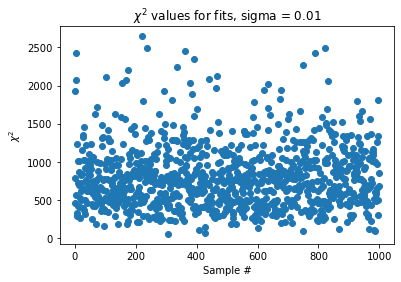

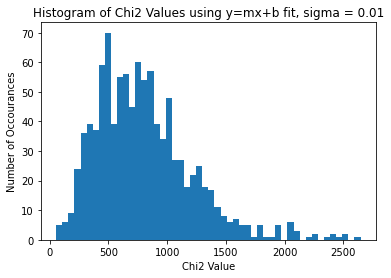

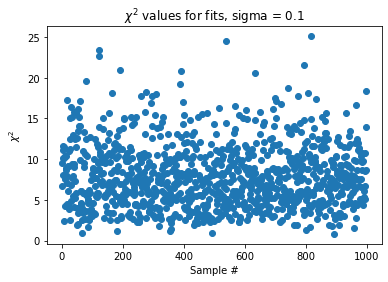

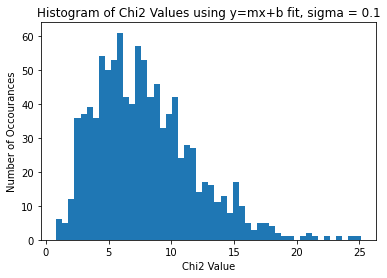

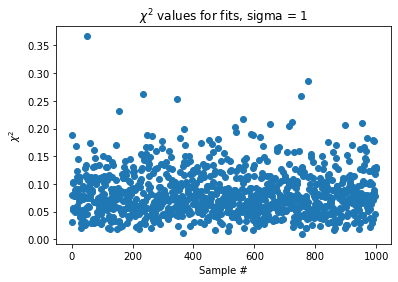

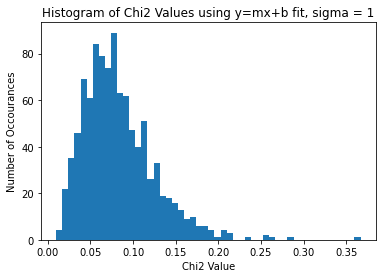

In [42]:
#Part c.) 
#lets change the assumed sigma within the chi2 calculation and show what happens
#I'll redo part b but change sigma to a really big and really small value

import numpy as np
import matplotlib.pyplot as plt

def Linear(x, slope, yint):
    return((slope*x) + yint)
sigma = [0.01, 0.1, 1]

for i in range(len(sigma)):
    # 10 evenly spaced data points between 0.1 and 1
    x = np.linspace(0.1, 1, 10)
    temp=[]
    for n in range(1000):
        # Randomly generate yi from y=x, varied by a Gaussian with sigma = 0.1
        yi = np.random.normal(x, 0.1)

        # Fit with a first-order polynomial (i.e. linear)
        fit = np.polyfit(x, yi, 1) 

        slope = fit[0]
        intercept = fit[1]
        chi2_fit = np.sum(
        ((yi - Linear(x, slope, intercept)) / sigma[i])**2 #since we assume f(x) = x
        )
        temp.append(chi2_fit)

    plt.scatter(range(1000), temp)    
    plt.title(r'$\chi^2$ values for fits, sigma = '+str(sigma[i]))
    plt.ylabel(r'$\chi^2$')
    plt.xlabel('Sample #')
    plt.show()

    plt.hist(temp, bins = 50)
    plt.title('Histogram of Chi2 Values using y=mx+b fit, sigma = '+str(sigma[i]))
    plt.xlabel('Chi2 Value')
    plt.ylabel('Number of Occourances')
    plt.show()
    
#super similar in looks but it's because matplotlib autoscales the yaxis.
#Low sigma = huge chi2, high sigma = way small chi2